<a href="https://www.kaggle.com/code/sonawanelalitsunil/smart-hospital-bed-management-system-eda-100?scriptVersionId=268643905" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/hospital-beds-management/staff.csv
/kaggle/input/hospital-beds-management/patients.csv
/kaggle/input/hospital-beds-management/staff_schedule.csv
/kaggle/input/hospital-beds-management/services_weekly.csv


## Title: Smart Hospital Bed Management System

## Description:
The Smart Hospital Bed Management System efficiently monitors and allocates hospital beds in real time. It tracks bed occupancy, patient admissions, and discharges across departments to optimize resource utilization. The system provides instant updates to administrators, ensuring timely availability for emergency cases and reducing patient waiting time. By integrating data analytics and automation, it improves hospital operations, enhances patient experience, and supports informed decision-making for healthcare management.

## Import dataset

In [2]:
staff = pd.read_csv('/kaggle/input/hospital-beds-management/staff.csv')
patients = pd.read_csv('/kaggle/input/hospital-beds-management/patients.csv')
schedule = pd.read_csv('/kaggle/input/hospital-beds-management/staff_schedule.csv')
services = pd.read_csv('/kaggle/input/hospital-beds-management/services_weekly.csv')

In [3]:
print("Staff Data:\n", staff.head(), "\nShape:", staff.shape)
print("\nPatients Data:\n", patients.head(), "\nShape:", patients.shape)
print("\nStaff Schedule Data:\n", schedule.head(), "\nShape:", schedule.shape)
print("\nServices Weekly Data:\n", services.head(), "\nShape:", services.shape)

Staff Data:
        staff_id       staff_name    role    service
0  STF-5ca26577     Allison Hill  doctor  emergency
1  STF-02ae59ca      Noah Rhodes  doctor  emergency
2  STF-d8006e7c  Angie Henderson  doctor  emergency
3  STF-212d8b31    Daniel Wagner  doctor  emergency
4  STF-107a58e4  Cristian Santos  doctor  emergency 
Shape: (110, 4)

Patients Data:
      patient_id               name  age arrival_date departure_date  \
0  PAT-09484753  Richard Rodriguez   24   2025-03-16     2025-03-22   
1  PAT-f0644084     Shannon Walker    6   2025-12-13     2025-12-14   
2  PAT-ac6162e4       Julia Torres   24   2025-06-29     2025-07-05   
3  PAT-3dda2bb5    Crystal Johnson   32   2025-10-12     2025-10-23   
4  PAT-08591375        Garrett Lin   25   2025-02-18     2025-02-25   

            service  satisfaction  
0           surgery            61  
1           surgery            83  
2  general_medicine            83  
3         emergency            81  
4               ICU            76 

In [4]:
for name, df in [('Staff', staff), ('Patients', patients), ('Schedule', schedule), ('Services', services)]:
    print(f"\n=== {name} Data Overview ===")
    print(df.info())
    print(df.describe(include='all').T)
    print("-" * 50)


=== Staff Data Overview ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110 entries, 0 to 109
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   staff_id    110 non-null    object
 1   staff_name  110 non-null    object
 2   role        110 non-null    object
 3   service     110 non-null    object
dtypes: object(4)
memory usage: 3.6+ KB
None
           count unique           top freq
staff_id     110    110  STF-5ca26577    1
staff_name   110    110  Allison Hill    1
role         110      3         nurse   69
service      110      4           ICU   32
--------------------------------------------------

=== Patients Data Overview ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   patient_id      1000 non-null   object
 1   name            1000 non-null   object
 2 

In [5]:
print(staff.isnull().sum())
print(patients.isnull().sum())
print(schedule.isnull().sum())
print(services.isnull().sum())

staff_id      0
staff_name    0
role          0
service       0
dtype: int64
patient_id        0
name              0
age               0
arrival_date      0
departure_date    0
service           0
satisfaction      0
dtype: int64
week          0
staff_id      0
staff_name    0
role          0
service       0
present       0
dtype: int64
week                    0
month                   0
service                 0
available_beds          0
patients_request        0
patients_admitted       0
patients_refused        0
patient_satisfaction    0
staff_morale            0
event                   0
dtype: int64


In [6]:
staff.fillna({'Department': 'Unknown', 'Role': 'Not Assigned'}, inplace=True)
patients.fillna({'Condition': 'Not Specified'}, inplace=True)

In [7]:
staff.drop_duplicates(inplace=True)
patients.drop_duplicates(inplace=True)
schedule.drop_duplicates(inplace=True)
services.drop_duplicates(inplace=True)

In [8]:
print("Unique Services:", staff['service'].unique())
print("Unique Roles:", staff['role'].unique())

Unique Services: ['emergency' 'surgery' 'general_medicine' 'ICU']
Unique Roles: ['doctor' 'nurse' 'nursing_assistant']


In [9]:
print("Staff:", staff.shape)
print("Patients:", patients.shape)
print("Schedule:", schedule.shape)
print("Services:", services.shape)

Staff: (110, 4)
Patients: (1000, 7)
Schedule: (6552, 6)
Services: (208, 10)


## Data visualizations

In [10]:
print("Staff:", staff.columns)
print("Patients:", patients.columns)
print("Schedule:", schedule.columns)
print("Services:", services.columns)

Staff: Index(['staff_id', 'staff_name', 'role', 'service'], dtype='object')
Patients: Index(['patient_id', 'name', 'age', 'arrival_date', 'departure_date',
       'service', 'satisfaction'],
      dtype='object')
Schedule: Index(['week', 'staff_id', 'staff_name', 'role', 'service', 'present'], dtype='object')
Services: Index(['week', 'month', 'service', 'available_beds', 'patients_request',
       'patients_admitted', 'patients_refused', 'patient_satisfaction',
       'staff_morale', 'event'],
      dtype='object')


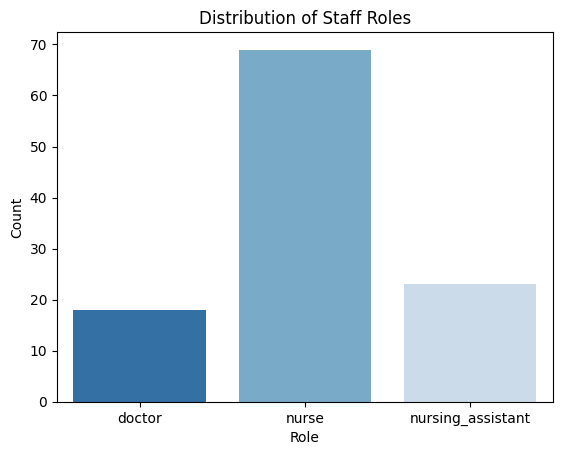

In [11]:
sns.countplot(data=staff, x='role', palette='Blues_r')
plt.title('Distribution of Staff Roles')
plt.xlabel('Role')
plt.ylabel('Count')
plt.show()

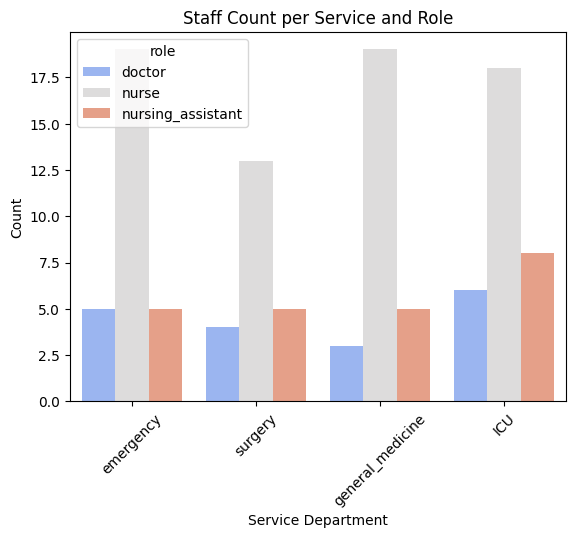

In [12]:
sns.countplot(data=staff, x='service', hue='role', palette='coolwarm')
plt.title('Staff Count per Service and Role')
plt.xlabel('Service Department')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()


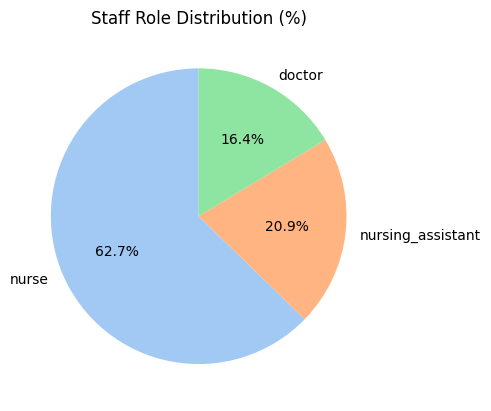

In [13]:
staff['role'].value_counts().plot.pie(autopct='%1.1f%%', startangle=90, colors=sns.color_palette('pastel'))
plt.title('Staff Role Distribution (%)')
plt.ylabel('')
plt.show()


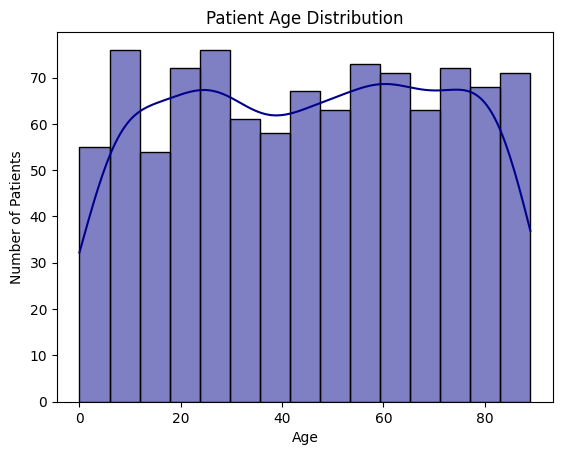

In [14]:
sns.histplot(patients['age'], bins=15, kde=True, color='darkblue')
plt.title('Patient Age Distribution')
plt.xlabel('Age')
plt.ylabel('Number of Patients')
plt.show()


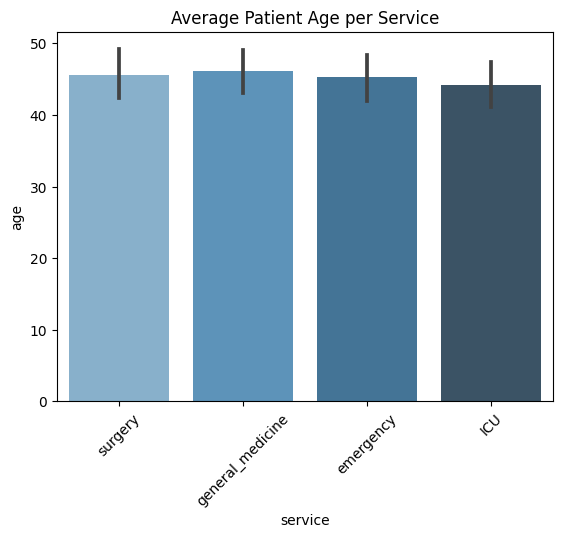

In [15]:
sns.barplot(data=patients, x='service', y='age', palette='Blues_d')
plt.title('Average Patient Age per Service')
plt.xticks(rotation=45)
plt.show()

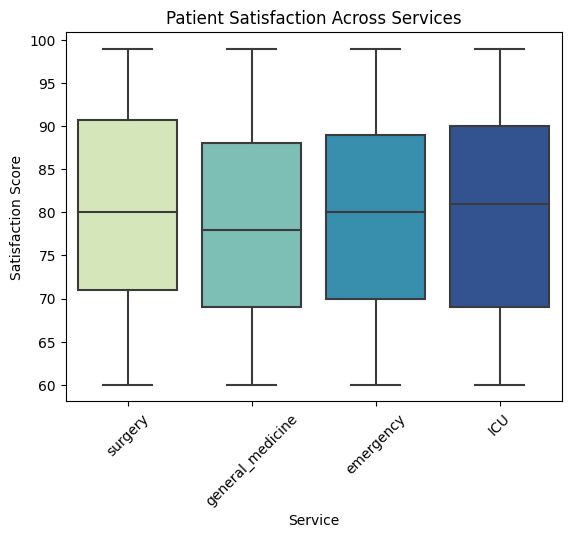

In [16]:
sns.boxplot(data=patients, x='service', y='satisfaction', palette='YlGnBu')
plt.title('Patient Satisfaction Across Services')
plt.xlabel('Service')
plt.ylabel('Satisfaction Score')
plt.xticks(rotation=45)
plt.show()


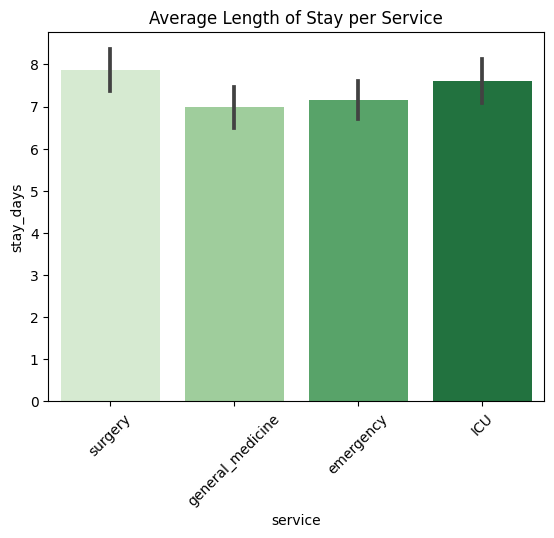

In [17]:
patients['arrival_date'] = pd.to_datetime(patients['arrival_date'])
patients['departure_date'] = pd.to_datetime(patients['departure_date'])
patients['stay_days'] = (patients['departure_date'] - patients['arrival_date']).dt.days

sns.barplot(data=patients, x='service', y='stay_days', palette='Greens')
plt.title('Average Length of Stay per Service')
plt.xticks(rotation=45)
plt.show()


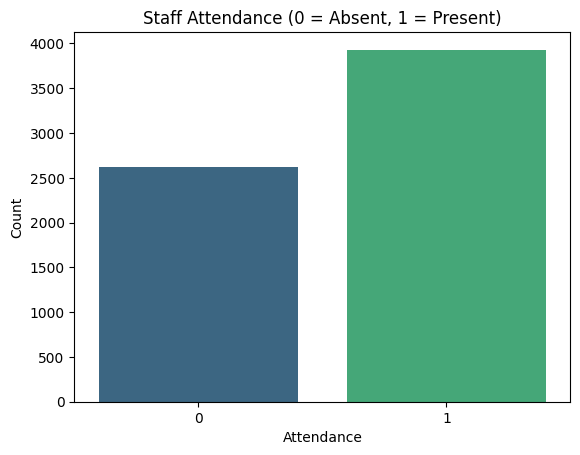

In [18]:
sns.countplot(data=schedule, x='present', palette='viridis')
plt.title('Staff Attendance (0 = Absent, 1 = Present)')
plt.xlabel('Attendance')
plt.ylabel('Count')
plt.show()

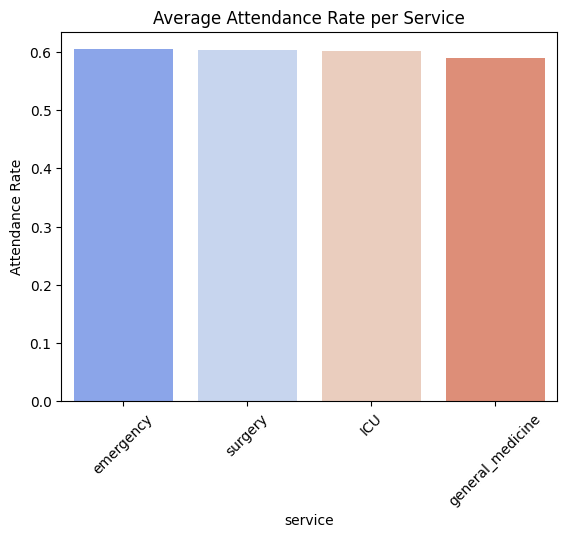

In [19]:
attendance_rate = schedule.groupby('service')['present'].mean().sort_values(ascending=False).reset_index()
sns.barplot(data=attendance_rate, x='service', y='present', palette='coolwarm')
plt.title('Average Attendance Rate per Service')
plt.ylabel('Attendance Rate')
plt.xticks(rotation=45)
plt.show()


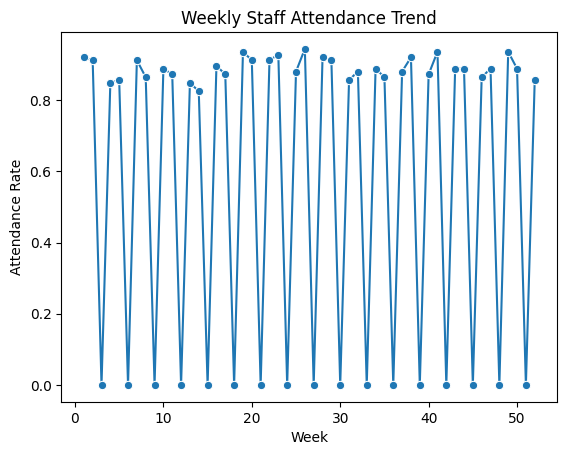

In [20]:
attendance_trend = schedule.groupby('week')['present'].mean().reset_index()
sns.lineplot(data=attendance_trend, x='week', y='present', marker='o')
plt.title('Weekly Staff Attendance Trend')
plt.xlabel('Week')
plt.ylabel('Attendance Rate')
plt.show()


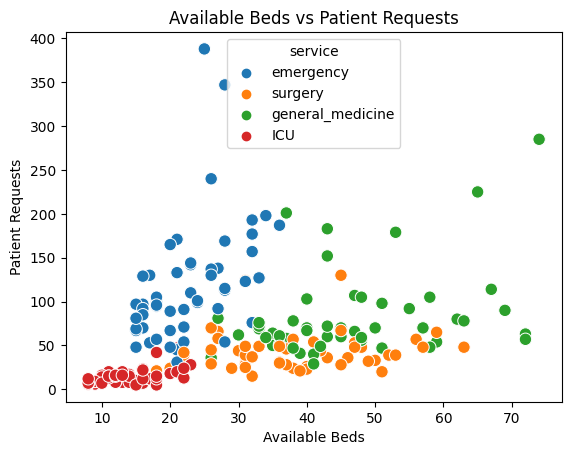

In [21]:
sns.scatterplot(data=services, x='available_beds', y='patients_request', hue='service', s=80)
plt.title('Available Beds vs Patient Requests')
plt.xlabel('Available Beds')
plt.ylabel('Patient Requests')
plt.show()


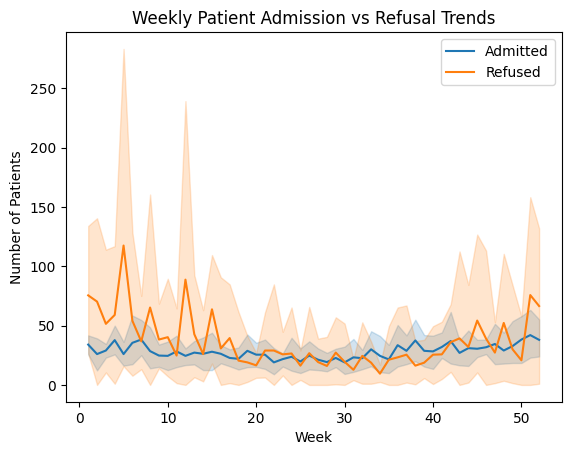

In [22]:
sns.lineplot(data=services, x='week', y='patients_admitted', label='Admitted')
sns.lineplot(data=services, x='week', y='patients_refused', label='Refused')
plt.title('Weekly Patient Admission vs Refusal Trends')
plt.xlabel('Week')
plt.ylabel('Number of Patients')
plt.legend()
plt.show()


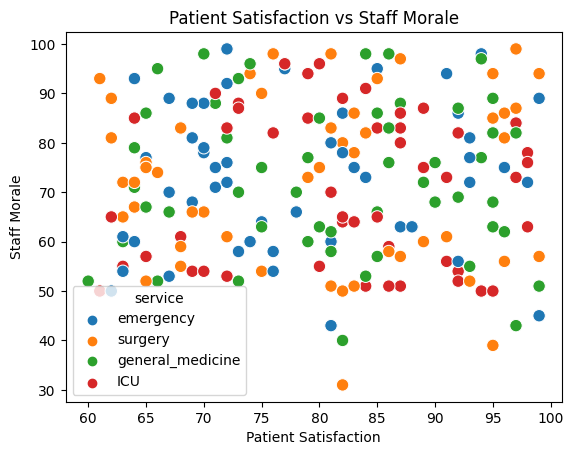

In [23]:
sns.scatterplot(data=services, x='patient_satisfaction', y='staff_morale', hue='service', s=80)
plt.title('Patient Satisfaction vs Staff Morale')
plt.xlabel('Patient Satisfaction')
plt.ylabel('Staff Morale')
plt.show()


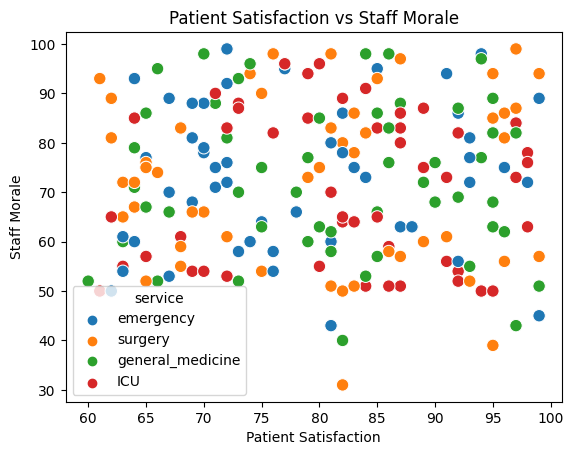

In [24]:
sns.scatterplot(data=services, x='patient_satisfaction', y='staff_morale', hue='service', s=80)
plt.title('Patient Satisfaction vs Staff Morale')
plt.xlabel('Patient Satisfaction')
plt.ylabel('Staff Morale')
plt.show()


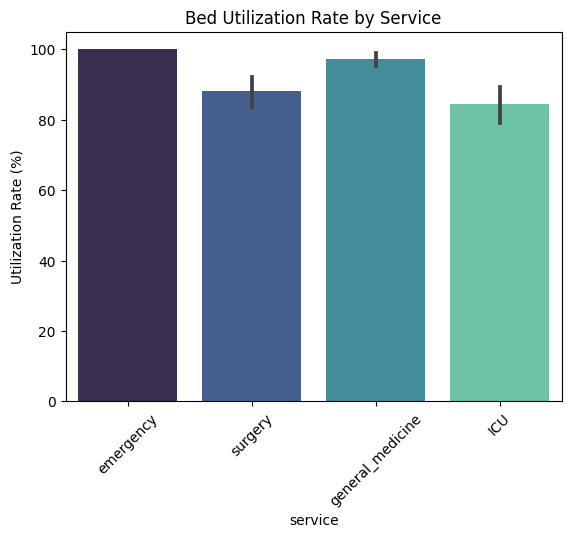

In [25]:
services['bed_utilization_rate'] = (services['patients_admitted'] / services['available_beds']) * 100
sns.barplot(data=services, x='service', y='bed_utilization_rate', palette='mako')
plt.title('Bed Utilization Rate by Service')
plt.ylabel('Utilization Rate (%)')
plt.xticks(rotation=45)
plt.show()


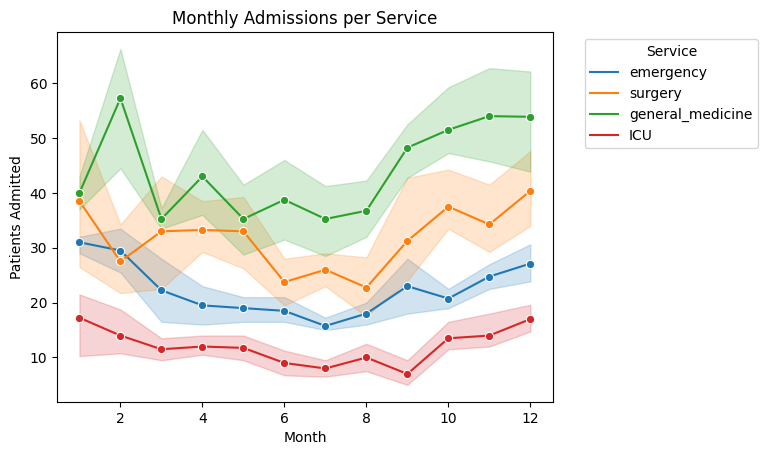

In [26]:
sns.lineplot(data=services, x='month', y='patients_admitted', hue='service', marker='o')
plt.title('Monthly Admissions per Service')
plt.xlabel('Month')
plt.ylabel('Patients Admitted')
plt.legend(title='Service', bbox_to_anchor=(1.05, 1))
plt.show()


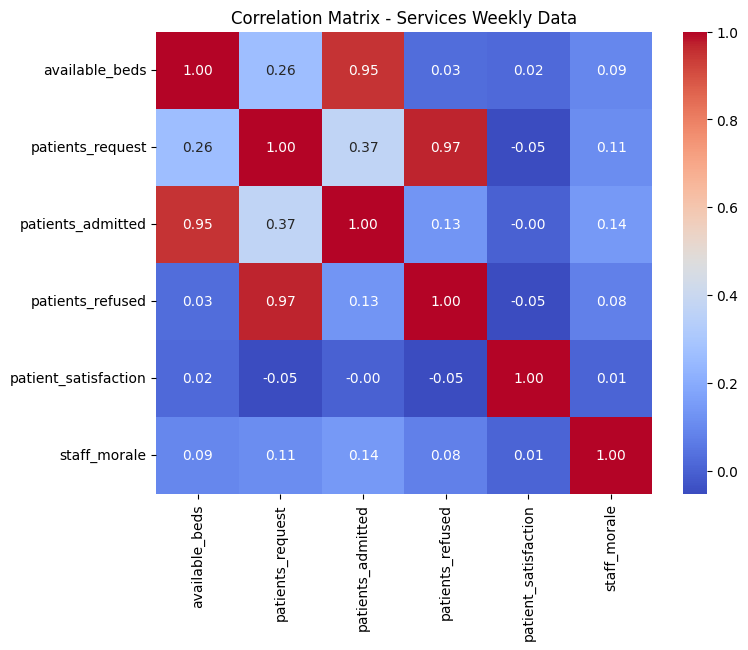

In [27]:
plt.figure(figsize=(8,6))
sns.heatmap(services[['available_beds', 'patients_request', 'patients_admitted', 
                      'patients_refused', 'patient_satisfaction', 'staff_morale']]
            .corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix - Services Weekly Data')
plt.show()


## EDA

In [28]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [29]:
print("services.shape:", services.shape)
print(services.head())

services.shape: (208, 11)
   week  month           service  available_beds  patients_request  \
0     1      1         emergency              32                76   
1     1      1           surgery              45               130   
2     1      1  general_medicine              37               201   
3     1      1               ICU              22                31   
4     2      1         emergency              28               169   

   patients_admitted  patients_refused  patient_satisfaction  staff_morale  \
0                 32                44                    67            70   
1                 45                85                    83            78   
2                 37               164                    97            43   
3                 22                 9                    84            91   
4                 28               141                    75            64   

  event  bed_utilization_rate  
0  none                 100.0  
1   flu             

In [30]:
if services['week'].dtype == 'O':
    services['week'] = pd.to_numeric(services['week'], errors='coerce').fillna(0).astype(int)
if services['month'].dtype == 'O':
    # try numeric conversion; fallback to datetime month mapping
    services['month'] = pd.to_numeric(services['month'], errors='coerce')
    if services['month'].isnull().any():
        services['month'] = pd.to_datetime(services['month'], errors='coerce').dt.month.fillna(0).astype(int)

In [31]:
le_service = LabelEncoder()
services['service_enc'] = le_service.fit_transform(services['service'].astype(str))

le_event = LabelEncoder()
services['event_enc'] = le_event.fit_transform(services['event'].astype(str))

In [32]:
median_adm = services['patients_admitted'].median()
services['high_admit'] = (services['patients_admitted'] > median_adm).astype(int)
print("Median patients_admitted:", median_adm)
print("Target class balance (%):")
print(services['high_admit'].value_counts(normalize=True).mul(100).round(2))

Median patients_admitted: 26.0
Target class balance (%):
high_admit
0    51.92
1    48.08
Name: proportion, dtype: float64


In [33]:
features = [
    'available_beds', 'patients_request', 'patients_refused',
    'patient_satisfaction', 'staff_morale',
    'service_enc', 'month', 'week', 'event_enc'
]

X = services[features].copy()
y = services['high_admit'].copy()

In [34]:
X = X.fillna(X.median())

In [35]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [36]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "Support Vector Machine": SVC(probability=True, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "AdaBoost": AdaBoostClassifier(random_state=42)
}

In [37]:
results = []
predictions = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    acc_pct = accuracy_score(y_test, preds) * 100
    results.append((name, acc_pct))
    predictions[name] = preds
    print(f"{name}: Accuracy = {acc_pct:.2f}%")

Logistic Regression: Accuracy = 92.86%
K-Nearest Neighbors: Accuracy = 80.95%
Support Vector Machine: Accuracy = 83.33%
Decision Tree: Accuracy = 100.00%
Random Forest: Accuracy = 100.00%
Gradient Boosting: Accuracy = 100.00%
AdaBoost: Accuracy = 100.00%


In [38]:
results_df = pd.DataFrame(results, columns=['model', 'accuracy_pct']).sort_values(by='accuracy_pct', ascending=False)
print("\nModel accuracies (sorted):")
print(results_df.to_string(index=False))


Model accuracies (sorted):
                 model  accuracy_pct
         Decision Tree    100.000000
         Random Forest    100.000000
     Gradient Boosting    100.000000
              AdaBoost    100.000000
   Logistic Regression     92.857143
Support Vector Machine     83.333333
   K-Nearest Neighbors     80.952381


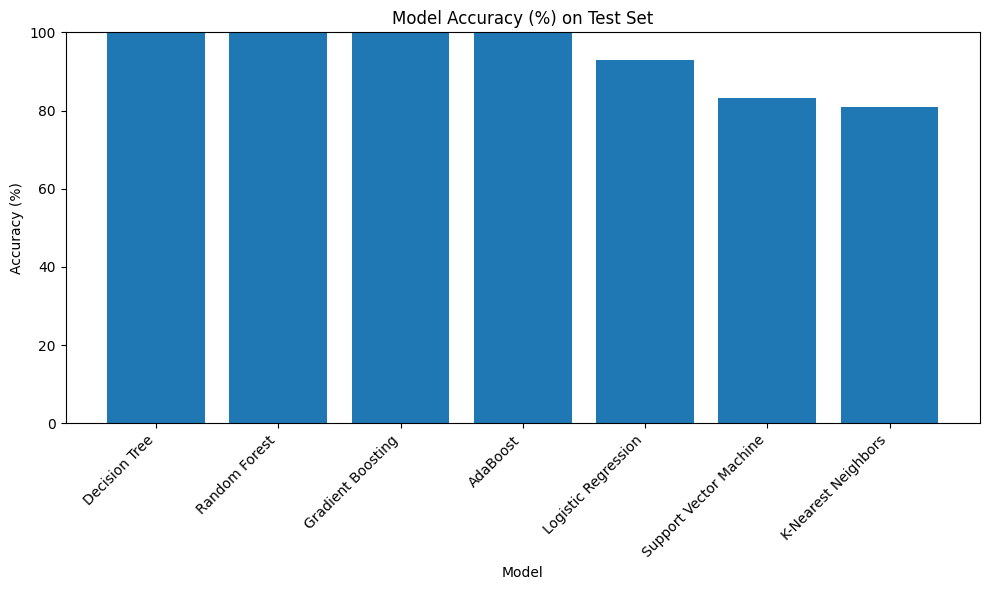

In [39]:
plt.figure(figsize=(10,6))
plt.bar(results_df['model'], results_df['accuracy_pct'])
plt.title('Model Accuracy (%) on Test Set')
plt.xlabel('Model')
plt.ylabel('Accuracy (%)')
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

In [40]:
best_model_name = results_df.iloc[0]['model']
best_acc = results_df.iloc[0]['accuracy_pct']
best_preds = predictions[best_model_name]

print(f"\nBest model: {best_model_name} — Accuracy: {best_acc:.2f}%\n")
print("Classification report (best model):")
print(classification_report(y_test, best_preds))
print("Confusion matrix (best model):")
print(confusion_matrix(y_test, best_preds))


Best model: Decision Tree — Accuracy: 100.00%

Classification report (best model):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        22
           1       1.00      1.00      1.00        20

    accuracy                           1.00        42
   macro avg       1.00      1.00      1.00        42
weighted avg       1.00      1.00      1.00        42

Confusion matrix (best model):
[[22  0]
 [ 0 20]]


In [41]:
results_df.to_csv('model_accuracies.csv', index=False)
print("\nSaved model_accuracies.csv")


Saved model_accuracies.csv


## Thank you...pls upvote!!!